# Interpretability — SHAP & LIME

This notebook applies two explainability methods to the trained U-Net segmentation model:

- **SHAP** (GradientExplainer): pixel-level gradient-based attributions showing which input regions drive the model's predictions.
- **LIME** (LimeImageExplainer): superpixel-based perturbation approach showing which image segments contribute most to the predicted tumor region.

Both methods help understand *why* the model segments a region as tumor.

In [ ]:
import os
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries

sys.path.append(os.path.abspath(".."))
from dataset import BrainTumorDataset
from torch.utils.data import DataLoader, random_split

BASE_DIR = os.path.dirname(os.getcwd())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cpu


In [ ]:
from model import UNet

model = UNet().to(device)

unet_path = os.path.join(BASE_DIR, "models", "unet.pt")
model.load_state_dict(torch.load(unet_path, map_location=device))
model.eval()
print(f"U-Net weights loaded from {unet_path}")


U-Net loaded.


In [6]:
import importlib
import dataset as dataset_module
importlib.reload(dataset_module)
from dataset import BrainTumorDataset

BASE_DIR = os.path.dirname(os.getcwd())

dataset = BrainTumorDataset(
    image_dir=os.path.join(BASE_DIR, "data/processed/images"),
    mask_dir=os.path.join(BASE_DIR, "data/processed/masks"),
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

images, masks = next(iter(val_loader))
images = images.to(device)
masks = masks.to(device)

print(f"Dataset: {len(dataset)} samples | Train: {train_size} | Val: {val_size}")
print(f"Sample batch — images: {images.shape}  masks: {masks.shape}")


Dataset: 253 samples | Train: 202 | Val: 51
Sample batch — images: torch.Size([16, 3, 256, 256])  masks: torch.Size([16, 1, 256, 256])


## SHAP — Gradient-Based Pixel Attribution

`shap.GradientExplainer` computes expected gradients with respect to a background dataset.  
For each pixel, the SHAP value indicates how much that pixel pushed the model's mean output (tumor probability) above or below the background average.

Positive values (red) = pixels that increase predicted tumor probability.  
Negative values (blue) = pixels that suppress it.

In [9]:
class UNetScalarWrapper(nn.Module):
    def __init__(self, unet):
        super().__init__()
        self.unet = unet

    def forward(self, x):
        seg_map = self.unet(x)
        return seg_map.mean(dim=[1, 2, 3], keepdim=False).unsqueeze(1)


scalar_model = UNetScalarWrapper(model).to(device)
scalar_model.eval()

background = images[:2]
test_images = images[2:6]
n_samples = len(test_images)

explainer = shap.GradientExplainer(scalar_model, background)
shap_values = explainer.shap_values(test_images)
shap_arr = np.array(shap_values)

print("SHAP values shape:", shap_arr.shape)
print("n_samples:", n_samples)


SHAP values shape: (4, 3, 256, 256, 1)
n_samples: 4


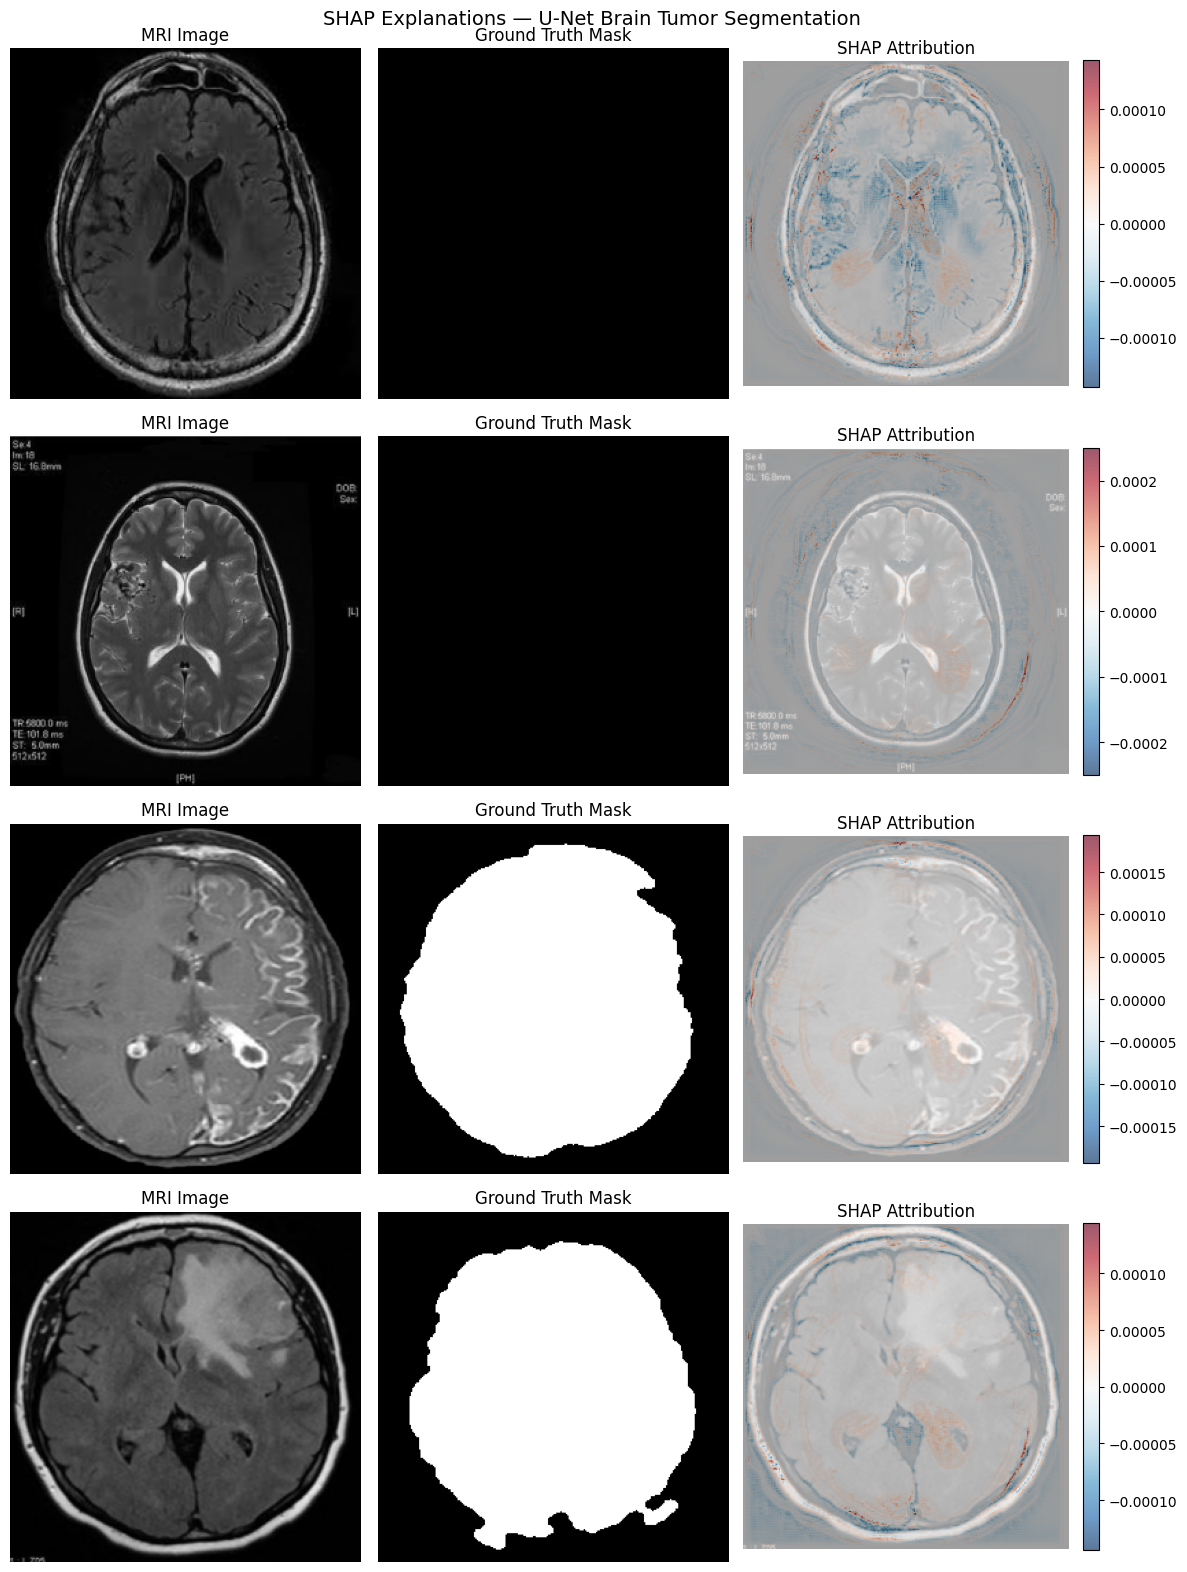

SHAP plot saved.


In [10]:
fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))

for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy()
    mask_np = masks[2 + i].cpu().squeeze().numpy()

    shap_map = shap_arr[i, :, :, :, 0].sum(axis=0)

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("MRI Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    vmax = np.abs(shap_map).max() + 1e-8
    axes[i, 2].imshow(img_np)
    im = axes[i, 2].imshow(shap_map, cmap="RdBu_r", alpha=0.65, vmin=-vmax, vmax=vmax)
    axes[i, 2].set_title("SHAP Attribution")
    axes[i, 2].axis("off")
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

plt.suptitle("SHAP Explanations — U-Net Brain Tumor Segmentation", fontsize=14)
plt.tight_layout()
os.makedirs(os.path.join(BASE_DIR, "reports"), exist_ok=True)
plt.savefig(os.path.join(BASE_DIR, "reports/shap_explanation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("SHAP plot saved.")


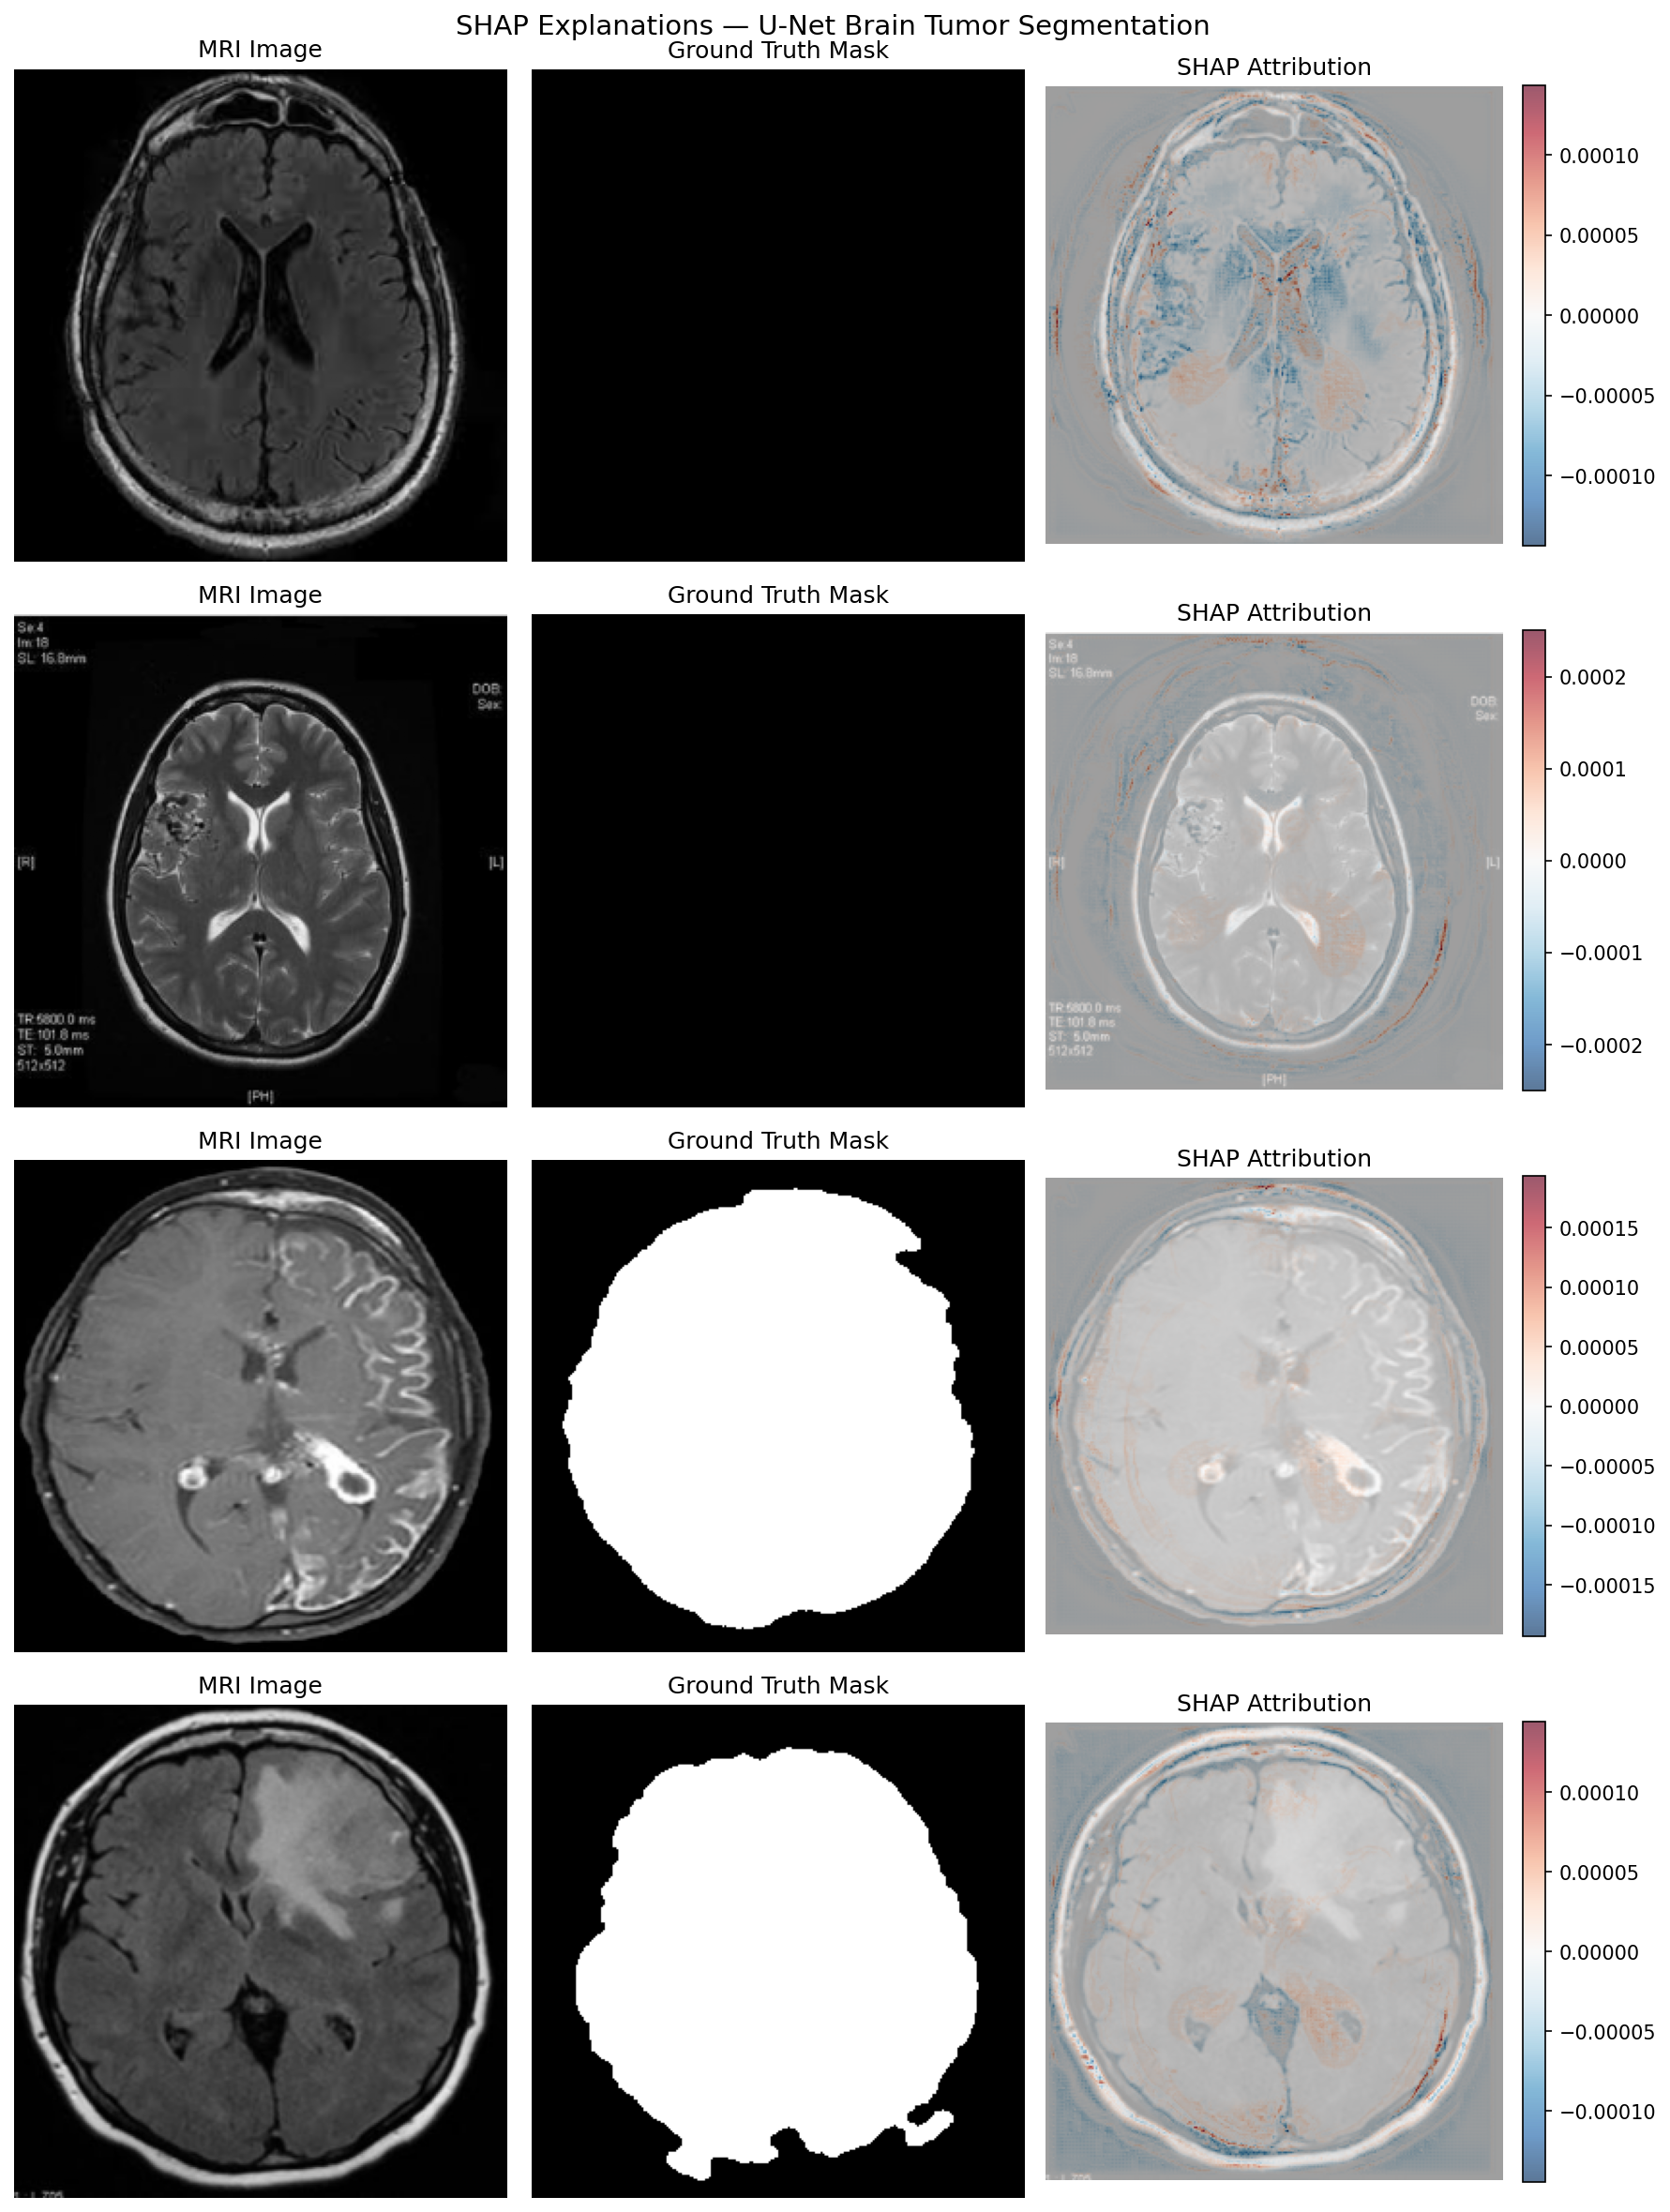

In [11]:
from IPython.display import Image, display
display(Image(filename=os.path.join(BASE_DIR, "reports/shap_explanation.png")))

## LIME — Superpixel Perturbation Analysis

`LimeImageExplainer` masks out groups of pixels (superpixels) and observes how the model's tumor probability score changes.  
Superpixels highlighted in green increase the predicted tumor score — i.e., they are the regions the model relies on most.

In [12]:
def lime_predict(images_np):
    batch = torch.tensor(images_np, dtype=torch.float32).permute(0, 3, 1, 2).to(device)
    with torch.no_grad():
        preds = model(batch)
    tumor_score = preds.mean(dim=[1, 2, 3]).cpu().numpy()
    no_tumor_score = 1.0 - tumor_score
    return np.stack([no_tumor_score, tumor_score], axis=1)


explainer_lime = lime_image.LimeImageExplainer()

lime_explanations = []
for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy().astype(np.float64)
    explanation = explainer_lime.explain_instance(
        img_np,
        lime_predict,
        top_labels=1,
        hide_color=0,
        num_samples=300,
    )
    lime_explanations.append(explanation)
    print(f"LIME explanation {i+1}/{n_samples} done.")


  0%|          | 0/300 [00:00<?, ?it/s]

LIME explanation 1/4 done.


  0%|          | 0/300 [00:00<?, ?it/s]

LIME explanation 2/4 done.


  0%|          | 0/300 [00:00<?, ?it/s]

LIME explanation 3/4 done.


  0%|          | 0/300 [00:00<?, ?it/s]

LIME explanation 4/4 done.


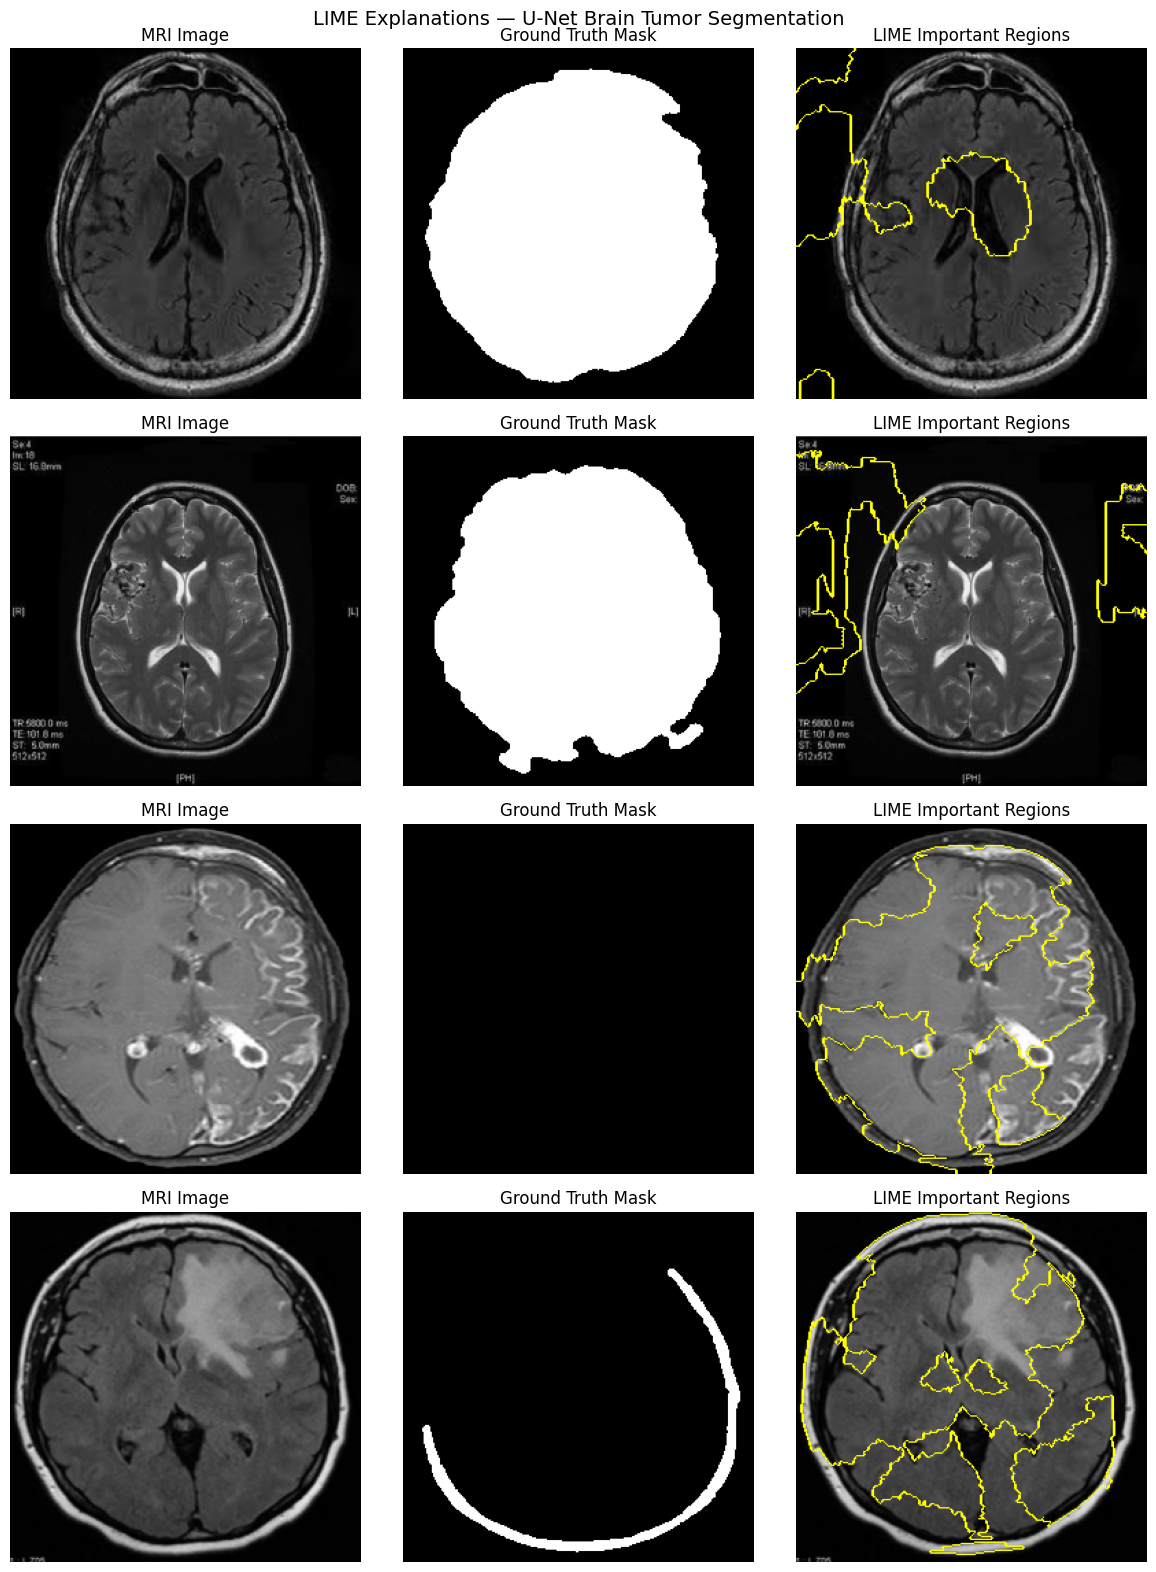

LIME plot saved to reports/lime_explanation.png


In [13]:
fig, axes = plt.subplots(n_samples, 3, figsize=(12, n_samples * 4))

for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy()
    mask_np = masks[4 + i].cpu().squeeze().numpy()
    exp = lime_explanations[i]

    top_label = exp.top_labels[0]
    temp, lime_mask = exp.get_image_and_mask(
        top_label,
        positive_only=True,
        num_features=10,
        hide_rest=False,
    )

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("MRI Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mark_boundaries(temp, lime_mask))
    axes[i, 2].set_title("LIME Important Regions")
    axes[i, 2].axis("off")

plt.suptitle("LIME Explanations — U-Net Brain Tumor Segmentation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports/lime_explanation.png"), dpi=150, bbox_inches="tight")
plt.show()
print("LIME plot saved to reports/lime_explanation.png")


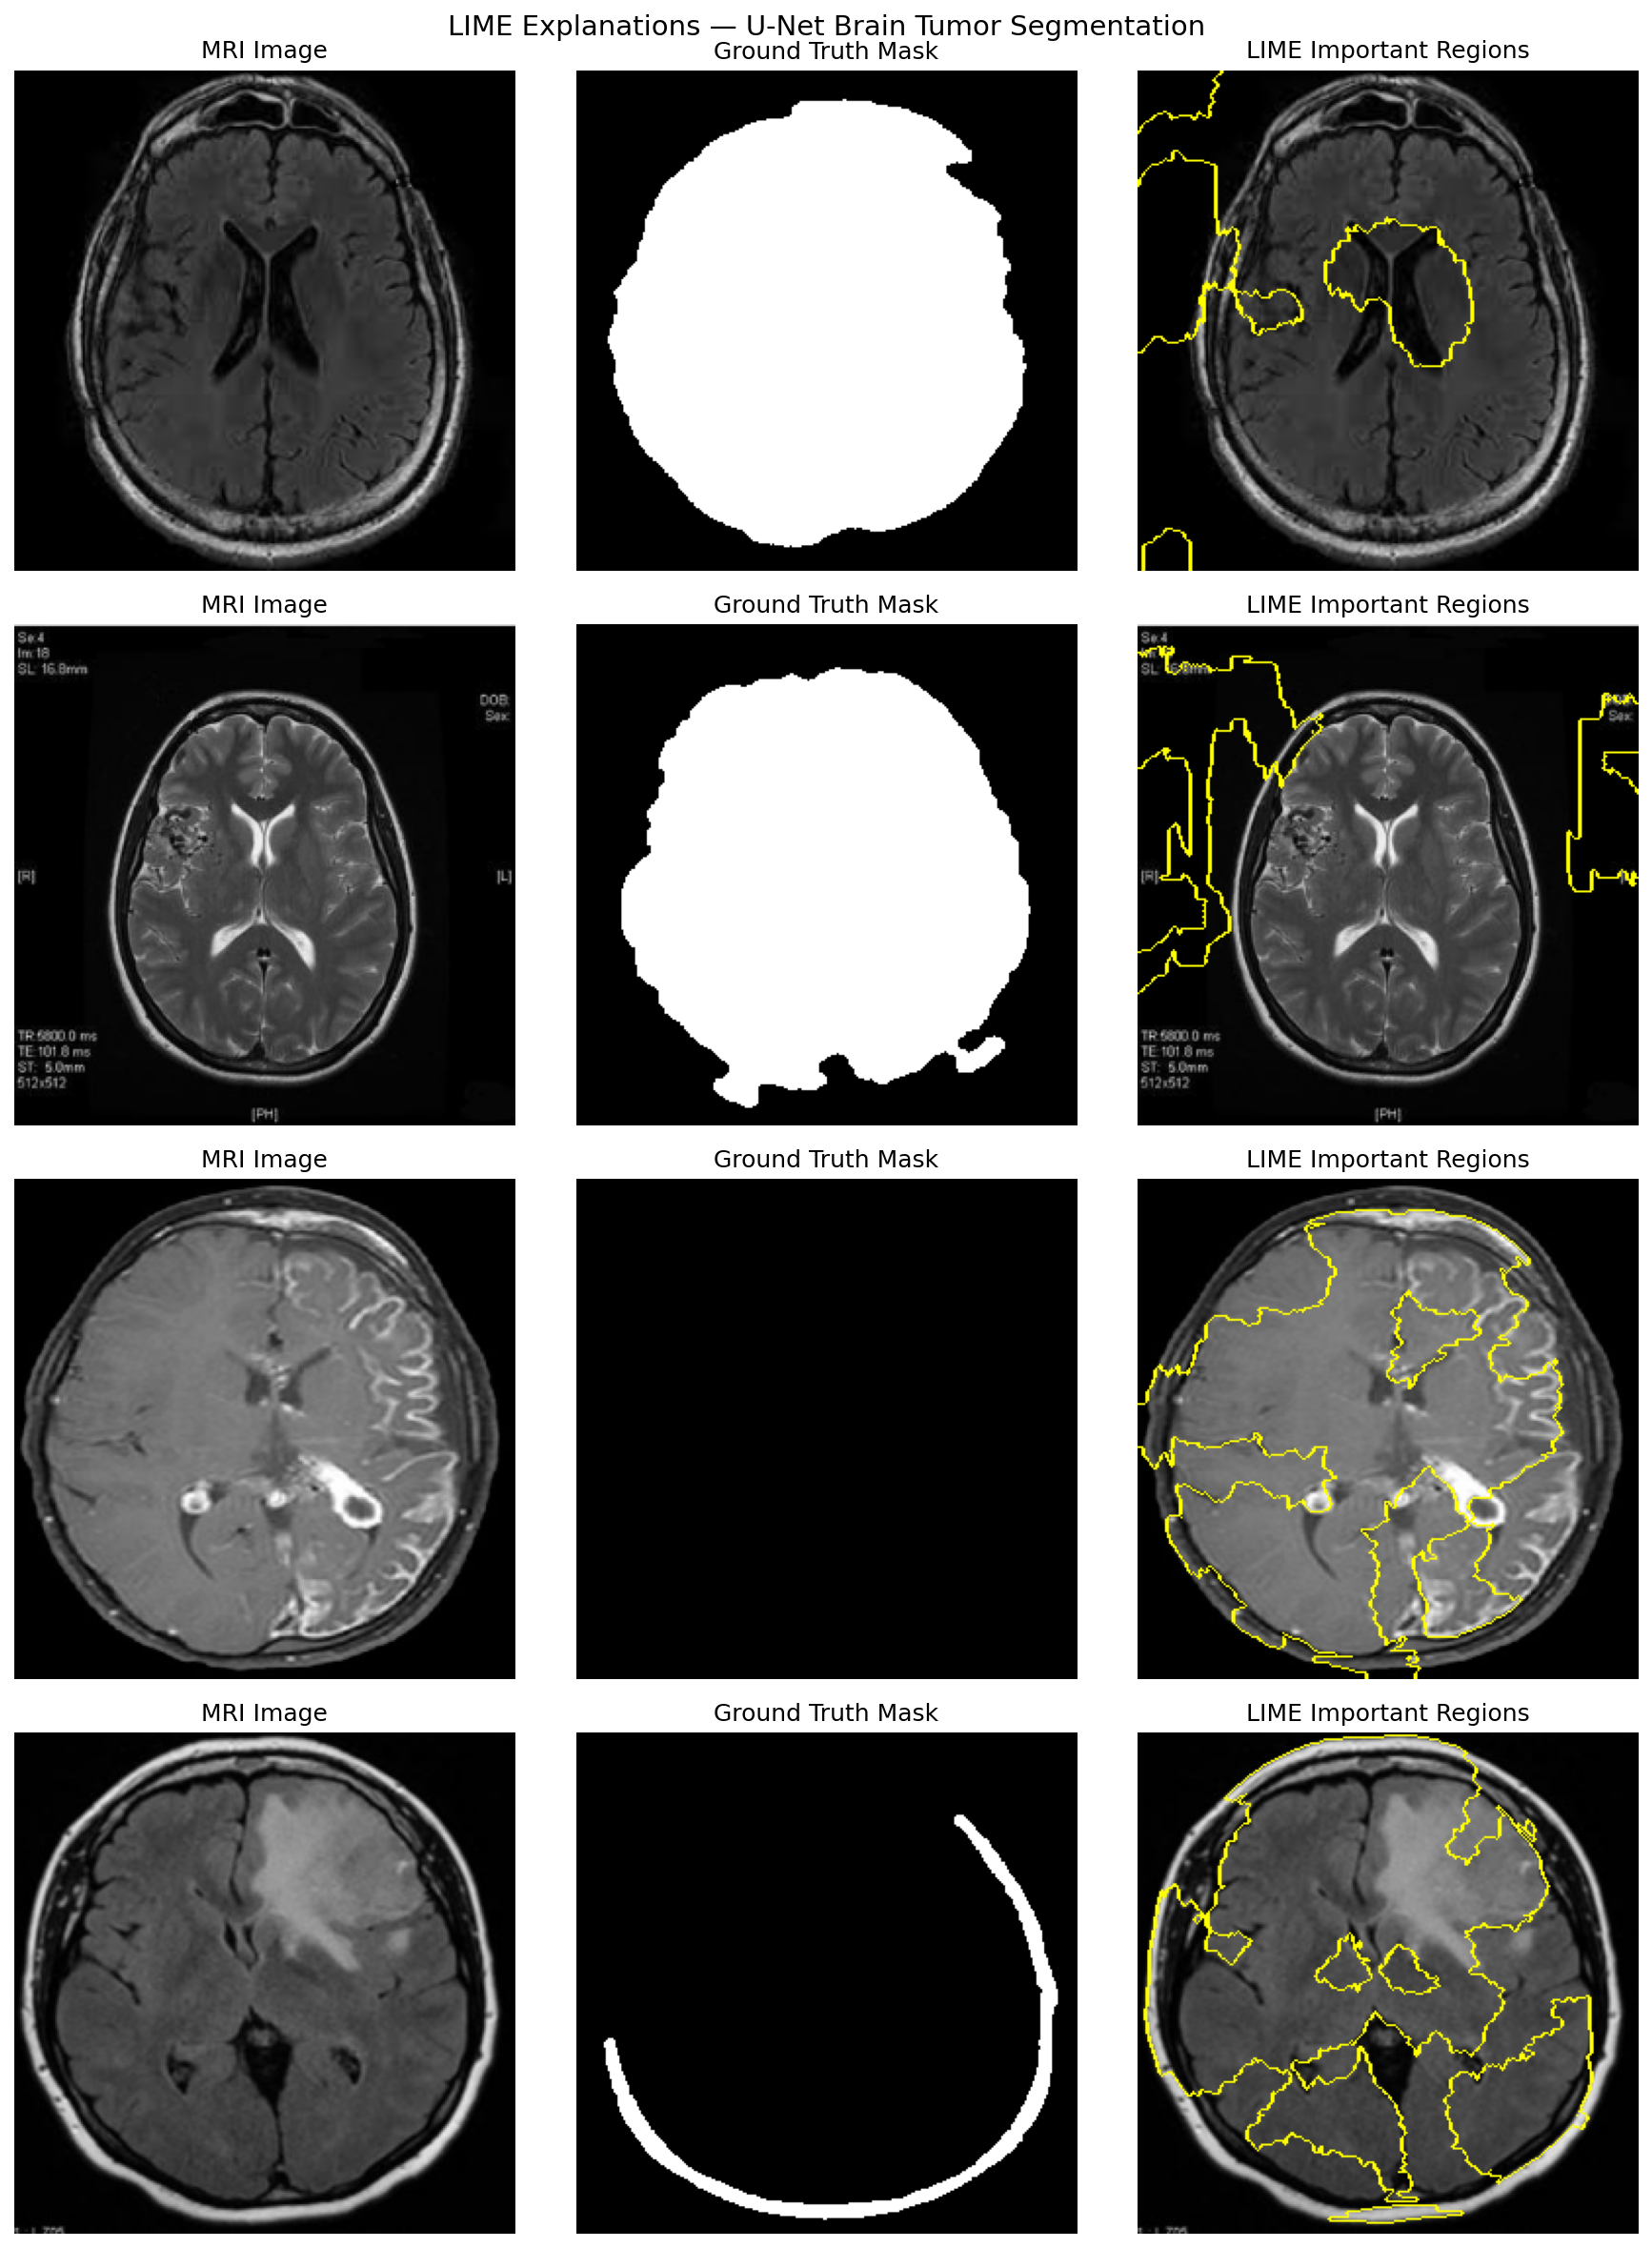

In [14]:
display(Image(filename=os.path.join(BASE_DIR, "reports/lime_explanation.png")))

## SHAP vs LIME — Side-by-Side Comparison

Both methods are shown together for the same samples so their explanations can be directly compared.

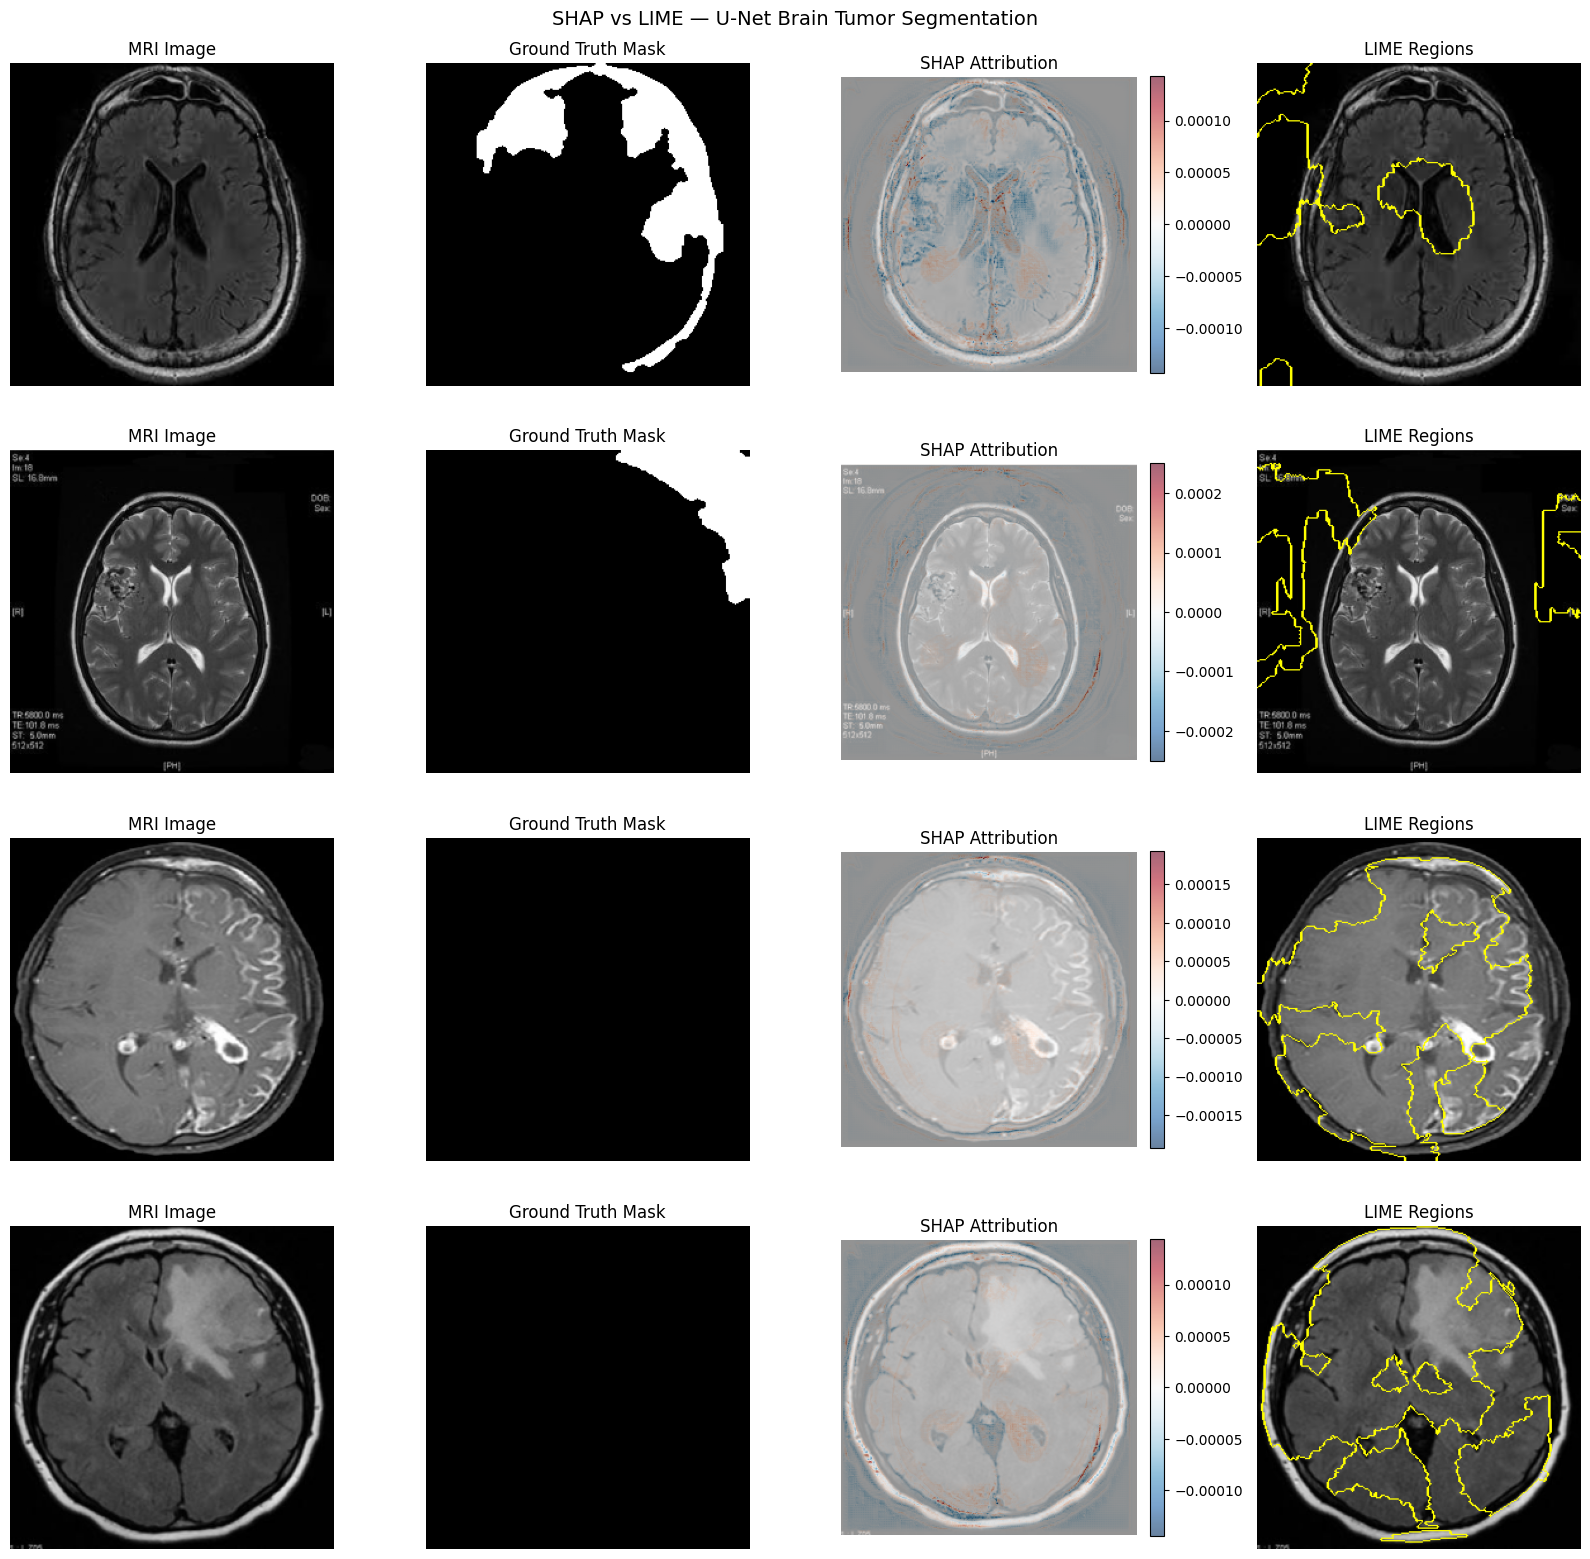

Comparison plot saved to reports/shap_vs_lime.png


In [15]:
fig, axes = plt.subplots(n_samples, 4, figsize=(16, n_samples * 4))

for i in range(n_samples):
    img_np = test_images[i].cpu().permute(1, 2, 0).numpy()
    mask_np = masks[i].cpu().squeeze().numpy()

    if shap_arr.ndim == 5:
        shap_map = shap_arr[i, :, :, :, 0].sum(axis=0)
    else:
        shap_map = shap_arr[0, i].sum(axis=0)

    vmax = np.abs(shap_map).max() + 1e-8

    exp = lime_explanations[i]
    top_label = exp.top_labels[0]
    temp, lime_mask = exp.get_image_and_mask(
        top_label, positive_only=True, num_features=10, hide_rest=False
    )

    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title("MRI Image")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_np, cmap="gray")
    axes[i, 1].set_title("Ground Truth Mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(img_np)
    im = axes[i, 2].imshow(shap_map, cmap="RdBu_r", alpha=0.6, vmin=-vmax, vmax=vmax)
    axes[i, 2].set_title("SHAP Attribution")
    axes[i, 2].axis("off")
    plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04)

    axes[i, 3].imshow(mark_boundaries(temp, lime_mask))
    axes[i, 3].set_title("LIME Regions")
    axes[i, 3].axis("off")

plt.suptitle("SHAP vs LIME — U-Net Brain Tumor Segmentation", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, "reports/shap_vs_lime.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Comparison plot saved to reports/shap_vs_lime.png")


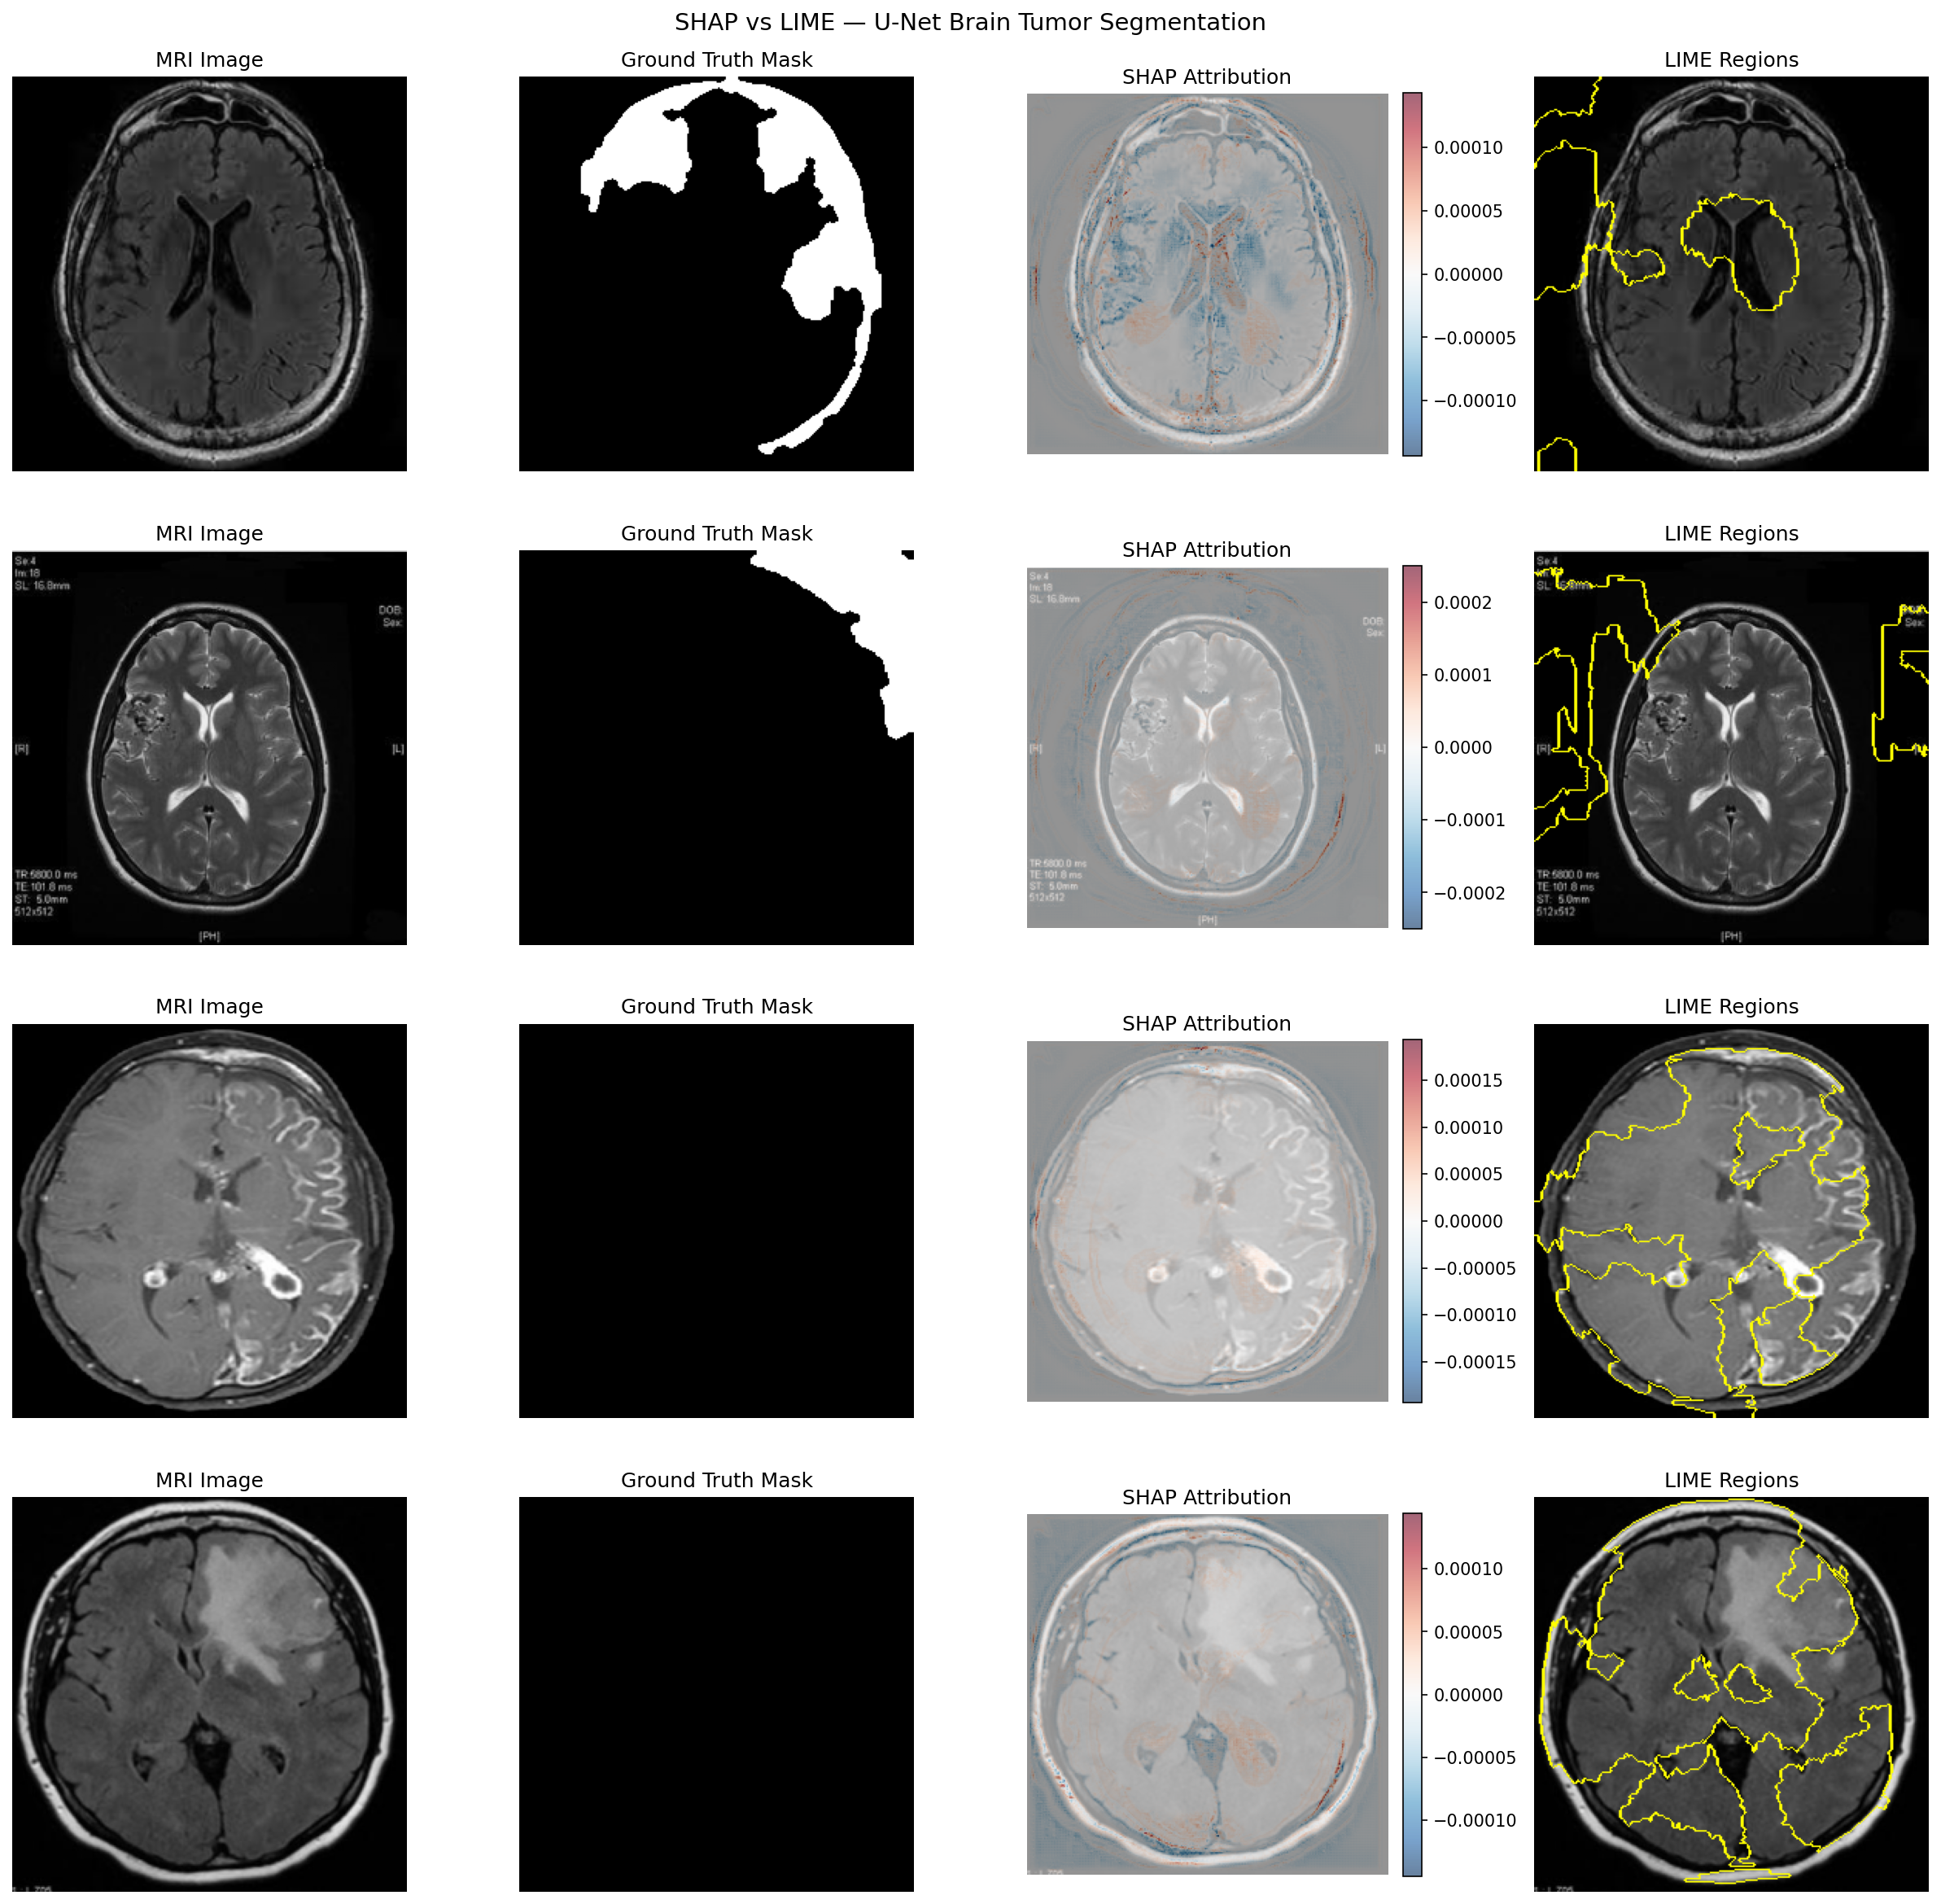

In [16]:
display(Image(filename=os.path.join(BASE_DIR, "reports/shap_vs_lime.png")))